# Skill-Based Job Role Predictor
## Notebook 2: Model Training and Evaluation

In this notebook we train and evaluate two classification models on the cleaned dataset.

**Goals:**
- Train K-Nearest Neighbors (KNN) and Support Vector Machine (SVM) classifiers
- Evaluate both models using k-fold cross-validation
- Compare models using accuracy, F1-score, and confusion matrix
- Save the best model for use in the web application


## 1. Loading the Cleaned Dataset
We load the dataset prepared in notebook 01.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv('../data/cleaned_dataset.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (570, 64)


,job_role,skills,skills_count,experience,skill_SQL,skill_Английский—_B2_—_Средне-продвинутый,skill_Английский_язык,skill_Python,skill_Docker,skill_Git,...,skill_Русский—_C1_—_Продвинутый,skill_Angular,skill_Apache_Kafka,skill_Laravel,skill_Adobe_Illustrator,skill_Анализ_данных,skill_Gitlab,skill_Golang,skill_Node_js,skill_Системный_анализ
0,Data Science / ML,Python; Математическая статистика; Исследовате...,4,2,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Data Science / ML,SQL; Анализ данных; Базы данных,3,2,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,Data Science / ML,Python; SQL; Numpy; pandas; Scikit-learn; CatB...,12,1,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,Data Science / ML,Python; SQL; Scikit-learn; Deep Learning; XGBo...,7,2,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Data Science / ML,Английский — B2 — Средне-продвинутый,1,2,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Defining Features and Target
We separate the dataset into:
- **X** is input features (skill columns + experience + skills_count)
- **y** is target variable (job_role)

In [43]:
skill_cols = [c for c in df.columns if c.startswith('skill_')]
feature_cols = skill_cols + ['experience', 'skills_count']

X = df[feature_cols]
y = df['job_role']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print()
print('Feature columns:')
print(feature_cols)

Features shape: (570, 62)
Target shape: (570,)

Feature columns:
['skill_SQL', 'skill_Английский—_B2_—_Средне-продвинутый', 'skill_Английский_язык', 'skill_Python', 'skill_Docker', 'skill_Git', 'skill_Kubernetes', 'skill_PostgreSQL', 'skill_CI_CD', 'skill_JavaScript', 'skill_Английский—_B1_—_Средний', 'skill_Бизнес-анализ', 'skill_Английский—_C1_—_Продвинутый', 'skill_Аналитическое_мышление', 'skill_REST_API', 'skill_TypeScript', 'skill_Linux', 'skill_React', 'skill_Figma', 'skill_Деловая_коммуникация', 'skill_BPMN', 'skill_Java', 'skill_API', 'skill_UML', 'skill_Redis', 'skill_MySQL', 'skill_Agile', 'skill_Power_BI', 'skill_UX', 'skill_Postman', 'skill_HTML', 'skill_Atlassian_Jira', 'skill_UI', 'skill_DevOps', 'skill_PHP', 'skill_Grafana', 'skill_Adobe_Photoshop', 'skill_Разработка_технических_заданий', 'skill_Русский—_C2_—_В_совершенстве', 'skill_MS_Excel', 'skill_User_Story', 'skill_REST', 'skill_RabbitMQ', 'skill_Scrum', 'skill_Постановка_задач_разработчикам', 'skill_QA', 'skill_Pr

## 3. Train/Test Split
We split the data into 80% training and 20% test set.
`stratify=y` ensures each job role is proportionally represented in both sets.
This is important because our dataset is imbalanced.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (456, 62)
Test set size: (114, 62)


## 4. K-Fold Cross-Validation
We use 5-fold cross-validation only to compare KNN and SVM and decide which one to use as our final model.

In k-fold cross-validation the data is split into k subsets. The model is trained k times, each time using a different subset as the test set. This gives us k evaluation scores which we average to get a final estimate.

We do not evaluate final performance here , that happens once on the test set after we pick the best model.

In [45]:
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)

knn_scores = cross_val_score(knn, X_train, y_train, cv=kf, scoring='f1_weighted')
svm_scores = cross_val_score(svm, X_train, y_train, cv=kf, scoring='f1_weighted')

print('KNN Mean F1:', round(knn_scores.mean(), 3), '± Std:', round(knn_scores.std(), 3))
print('SVM Mean F1:', round(svm_scores.mean(), 3), '± Std:', round(svm_scores.std(), 3))

KNN Mean F1: 0.262 ± Std: 0.033
SVM Mean F1: 0.171 ± Std: 0.024


## 5. Training and Evaluating Both Models
We train both KNN and SVM on the training set and evaluate them on the test set.
We compare accuracy and F1 weighted score to select the best model.

In [46]:
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)

knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
svm_pred = svm.predict(X_test)

print('KNN Accuracy:', round(accuracy_score(y_test, knn_pred), 3))
print('KNN F1 Weighted:', round(f1_score(y_test, knn_pred, average='weighted', zero_division=0), 3))
print()
print('SVM Accuracy:', round(accuracy_score(y_test, svm_pred), 3))
print('SVM F1 Weighted:', round(f1_score(y_test, svm_pred, average='weighted', zero_division=0), 3))

KNN Accuracy: 0.36
KNN F1 Weighted: 0.346

SVM Accuracy: 0.333
SVM F1 Weighted: 0.322


## 6. Classification Report
A detailed breakdown of precision, recall, and F1-score for each job role for both models.

In [47]:
print('KNN Classification Report:')
print(classification_report(y_test, knn_pred, zero_division=0))
print()
print('SVM Classification Report:')
print(classification_report(y_test, svm_pred, zero_division=0))

KNN Classification Report:
                    precision    recall  f1-score   support

 Backend Developer       0.18      0.14      0.16        14
  Business Analyst       0.43      0.60      0.50        15
      Data Analyst       0.33      0.45      0.38        11
 Data Science / ML       0.43      0.43      0.43         7
   DevOps Engineer       0.40      0.17      0.24        12
Frontend Developer       0.40      0.40      0.40        15
   Product Manager       0.31      0.29      0.30        14
       QA Engineer       0.41      0.54      0.47        13
       UX Designer       0.30      0.23      0.26        13

          accuracy                           0.36       114
         macro avg       0.35      0.36      0.35       114
      weighted avg       0.35      0.36      0.35       114


SVM Classification Report:
                    precision    recall  f1-score   support

 Backend Developer       0.16      0.21      0.18        14
  Business Analyst       0.67      0.13  

## 7. Improving the Models

Both KNN and SVM performed poorly with their default settings.
This is expected as default settings are just a starting point, not the best configuration.

**Tune the models**
Every model has parameters that control how it learns.
For KNN the key parameter is `n_neighbors`: how many nearby points to look at when making a prediction.
For SVM the key parameter is `C`: how strict the decision boundary is.

We will try multiple values for each parameter and let the algorithm find the best combination.
This process is called hyperparameter tuning.

After tuning both models we compare them and pick the winner.

In [48]:
from sklearn.model_selection import GridSearchCV

X_merged = df[feature_cols]
y_merged = df['job_role']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_merged, y_merged, test_size=0.2, random_state=42, stratify=y_merged
)

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 15]}
svm_params = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=kf, scoring='f1_weighted')
svm_grid = GridSearchCV(SVC(class_weight='balanced', random_state=42, probability=True), svm_params, cv=kf, scoring='f1_weighted')

knn_grid.fit(X_train_m, y_train_m)
svm_grid.fit(X_train_m, y_train_m)

print('KNN best params:', knn_grid.best_params_)
print('KNN best cross-validation F1:', round(knn_grid.best_score_, 3))
print()
print('SVM best params:', svm_grid.best_params_)
print('SVM best cross-validation F1:', round(svm_grid.best_score_, 3))

KNN best params: {'n_neighbors': 15}
KNN best cross-validation F1: 0.267

SVM best params: {'C': 10, 'kernel': 'rbf'}
SVM best cross-validation F1: 0.398


## 8. Final Evaluation
Tuned SVM scored 0.414 vs tuned KNN at 0.275 in cross-validation.
We select SVM with C=10 and rbf kernel as our final model.
We now evaluate it once on the test set.

In [49]:
best_model = svm_grid.best_estimator_
y_pred = best_model.predict(X_test_m)

print('Accuracy:', round(accuracy_score(y_test_m, y_pred), 3))
print('F1 Weighted:', round(f1_score(y_test_m, y_pred, average='weighted', zero_division=0), 3))
print()
print(classification_report(y_test_m, y_pred, zero_division=0))

Accuracy: 0.509
F1 Weighted: 0.512

                    precision    recall  f1-score   support

 Backend Developer       0.50      0.29      0.36        14
  Business Analyst       0.82      0.60      0.69        15
      Data Analyst       0.40      0.36      0.38        11
 Data Science / ML       0.22      0.29      0.25         7
   DevOps Engineer       0.62      0.42      0.50        12
Frontend Developer       0.53      0.60      0.56        15
   Product Manager       0.36      0.86      0.51        14
       QA Engineer       0.78      0.54      0.64        13
       UX Designer       0.67      0.46      0.55        13

          accuracy                           0.51       114
         macro avg       0.54      0.49      0.49       114
      weighted avg       0.57      0.51      0.51       114



## 9. Confusion Matrix
The confusion matrix shows exactly where the model makes mistakes.
Each row represents the actual job role, each column represents the predicted job role.
The diagonal shows correct predictions , everything off the diagonal is a mistake.

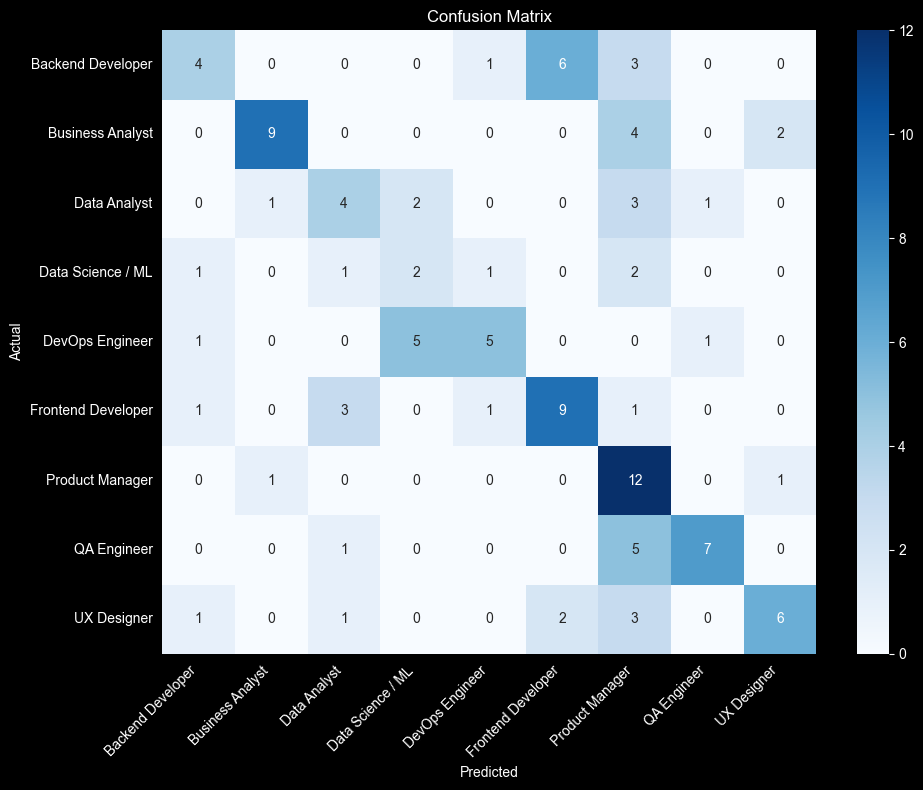

In [50]:
cm = confusion_matrix(y_test_m, y_pred, labels=best_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation**:
The model performs best on Product Manager (12/14 correct), Business Analyst (9/15), and Frontend Developer (9/15).

The biggest struggles are Backend Developer (4/14) which gets frequently confused with Frontend Developer due to shared skills like JavaScript and Git, and Data Science / ML (2/7) which overlaps heavily with Data Analyst.

The most common pattern is that technically similar roles get confused with each other. Product Manager absorbs many wrong predictions from other roles because its skills like Agile, Scrum, and Jira appear across many job listings.

## 10. Saving the Model
We save the trained model and the feature column list.
The Streamlit app will load both to make predictions on new data.
The column list ensures the app builds the input vector in the exact same order the model was trained on.

In [51]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(feature_cols, '../models/feature_columns.pkl')

print('Model saved to models/best_model.pkl')
print('Feature columns saved to models/feature_columns.pkl')

Model saved to models/best_model.pkl
Feature columns saved to models/feature_columns.pkl


## 11. Saving Top Skills for the App
We save the top 20 most frequent skills to use in the Streamlit app.

In [52]:
skill_cols_only = [c for c in feature_cols if c.startswith('skill_')]
top_skills = df[skill_cols_only].sum().sort_values(ascending=False).head(20).index.tolist()

print('Top 20 skills:')
for s in top_skills:
    print(s.replace('skill_', ''))

joblib.dump(top_skills, '../models/top_skills.pkl')
print()
print('Top skills saved to models/top_skills.pkl')

Top 20 skills:
SQL
Английский—_B2_—_Средне-продвинутый
Английский_язык
Python
Docker
Git
Kubernetes
PostgreSQL
CI_CD
JavaScript
Английский—_B1_—_Средний
Бизнес-анализ
Английский—_C1_—_Продвинутый
Аналитическое_мышление
REST_API
TypeScript
Linux
React
Figma
Деловая_коммуникация

Top skills saved to models/top_skills.pkl
